# SFT Data Comparison (General)

Compare SFT training data across **two or more** trajectory sets.

Configure the datasets in the cell below, then run all cells.

In [42]:
import json
import re
import os
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
import numpy as np

## Configuration

Define datasets as a list of `(name, path)` tuples. Add as many as you need.

In [43]:
# ============================================================
# CONFIGURE DATASETS HERE
# Each entry: (display_name, path_to_jsonl)
# ============================================================

SFT_BASE = (
    "/home/v-murongma/code/OpenHands_SWE-Bench-Optimized/evaluation/evaluation_outputs/outputs/"
    "SWE-Gym__SWE-Gym-train/CodeActAgent/"
    "Qwen3-Coder-480B-A35B-Instruct_maxiter_100_N_v0.61.0-no-hint-train-qwen3_coder_480b_a35b_instruct-t05/"
    "Qwen3-Coder-480B-A35B-Instruct_maxiter_100_N_v0.61.0-no-hint-train-qwen3_coder_480b_a35b_instruct-t05-run_1/sft"
)

DATASETS = [
    # ("Oracle", os.path.join(SFT_BASE, "oracle_traj_128k_swegym_resolved_632i.jsonl")),
    # ("Policy", os.path.join(SFT_BASE, "policy_traj_128k_swegym_resolved_634i.jsonl")),
    # Add more datasets here:
    # ("My Run", "/path/to/my_sft.jsonl"),
    ("glm5_thinking", "/home/v-murongma/code/OpenHands_SWE-Bench-Optimized/evaluation/evaluation_outputs/outputs_thin/SWE-Gym__SWE-Gym-train/CodeActAgent/GLM-5-FP8_maxiter_100_N_v0.61.0-thin-no-hint-glm5_fp8_t05_thinking/sft/policy_traj_128k_swegym_resolved_752i.jsonl"),
    ("qwen3", os.path.join(SFT_BASE, "policy_traj_128k_swegym_resolved_634i.jsonl")),
]

# Color palette (auto-extends if more datasets than colors)
COLORS = ["#4C72B0", "#C44E52", "#55A868", "#8172B2", "#CCB974", "#64B5CD", "#E07B39", "#8C8C8C"]

for name, path in DATASETS:
    print(f"{name}: exists={os.path.exists(path)}  [{path}]")

glm5_thinking: exists=True  [/home/v-murongma/code/OpenHands_SWE-Bench-Optimized/evaluation/evaluation_outputs/outputs_thin/SWE-Gym__SWE-Gym-train/CodeActAgent/GLM-5-FP8_maxiter_100_N_v0.61.0-thin-no-hint-glm5_fp8_t05_thinking/sft/policy_traj_128k_swegym_resolved_752i.jsonl]
qwen3: exists=True  [/home/v-murongma/code/OpenHands_SWE-Bench-Optimized/evaluation/evaluation_outputs/outputs/SWE-Gym__SWE-Gym-train/CodeActAgent/Qwen3-Coder-480B-A35B-Instruct_maxiter_100_N_v0.61.0-no-hint-train-qwen3_coder_480b_a35b_instruct-t05/Qwen3-Coder-480B-A35B-Instruct_maxiter_100_N_v0.61.0-no-hint-train-qwen3_coder_480b_a35b_instruct-t05-run_1/sft/policy_traj_128k_swegym_resolved_634i.jsonl]


## 1. Load SFT Data

In [44]:
def get_color(i):
    return COLORS[i % len(COLORS)]

def load_sft(path):
    """Load SFT JSONL into a list of message lists."""
    data = []
    with open(path) as f:
        for line in f:
            entry = json.loads(line)
            data.append(entry["messages"])
    return data

sft_data = {}  # name -> list of message lists
for name, path in DATASETS:
    print(f"Loading {name}...")
    sft_data[name] = load_sft(path)
    print(f"  Loaded {len(sft_data[name])} entries")

NAMES = [name for name, _ in DATASETS]

Loading glm5_thinking...
  Loaded 752 entries
Loading qwen3...
  Loaded 634 entries


## 2. Dataset Size Overview

glm5_thinking: 752 entries
qwen3: 634 entries


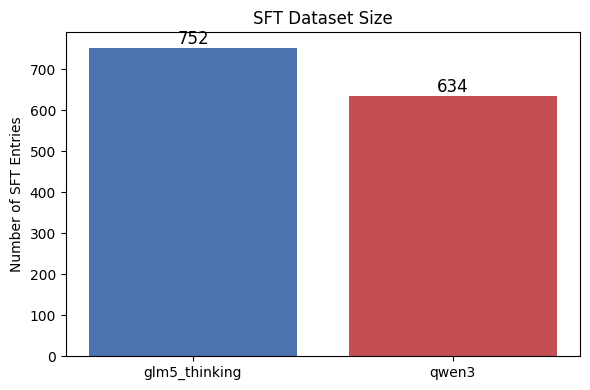

In [45]:
for name in NAMES:
    print(f"{name}: {len(sft_data[name])} entries")

fig, ax = plt.subplots(figsize=(max(6, 2 * len(NAMES)), 4))
counts = [len(sft_data[name]) for name in NAMES]
bars = ax.bar(NAMES, counts, color=[get_color(i) for i in range(len(NAMES))])
ax.bar_label(bars, fontsize=12)
ax.set_ylabel("Number of SFT Entries")
ax.set_title("SFT Dataset Size")
plt.tight_layout()
plt.show()

## 3. SFT Data Analysis Helpers

In [46]:
def normalize_command(cmd):
    """Normalize a command string by collapsing whitespace for fingerprinting."""
    if not cmd:
        return ""
    return re.sub(r'\s+', ' ', cmd).strip()

def make_sft_fingerprint(content):
    """Create a normalized fingerprint from an assistant message's content.
    
    Parses the XML-parameter format used in SFT data:
      <function=name>
      <parameter=key>value</parameter>
      </function>
    """
    func_match = re.search(r'<function=(\w+)>', content)
    if func_match:
        func_name = func_match.group(1)
        # Extract <parameter=key>value</parameter> pairs
        params = {}
        for pm in re.finditer(r'<parameter=(\w+)>(.*?)</parameter>', content, re.DOTALL):
            params[pm.group(1)] = pm.group(2).strip()
        
        if func_name in ('str_replace_editor', 'edit'):
            cmd = params.get('command', '')
            path = params.get('path', '')
            old_str = normalize_command(params.get('old_str', ''))[:100]
            new_str = normalize_command(params.get('new_str', ''))[:100]
            if cmd == 'str_replace':
                return f"{func_name}:str_replace:{path}:{old_str}->{new_str}"
            elif cmd == 'view':
                view_range = params.get('view_range', '')
                return f"{func_name}:view:{path}:{view_range}"
            elif cmd == 'create':
                return f"{func_name}:create:{path}"
            else:
                return f"{func_name}:{cmd}:{path}"
        elif func_name == 'execute_bash':
            cmd = normalize_command(params.get('command', ''))[:150]
            return f"execute_bash:{cmd}"
        elif func_name == 'think':
            return "think"
        else:
            path = params.get('path', params.get('file_name', ''))
            cmd = normalize_command(params.get('command', ''))[:100]
            return f"{func_name}:{path}:{cmd}" if cmd else f"{func_name}:{path}"

    # Fallback: <execute_bash>...</execute_bash> tags
    bash_match = re.search(r'<execute_bash>(.*?)</execute_bash>', content, re.DOTALL)
    if bash_match:
        return f"execute_bash:{normalize_command(bash_match.group(1))[:150]}"

    # Fallback: <execute_ipython>...</execute_ipython> tags
    ipython_match = re.search(r'<execute_ipython>(.*?)</execute_ipython>', content, re.DOTALL)
    if ipython_match:
        return f"execute_ipython:{normalize_command(ipython_match.group(1))[:150]}"

    return "text_only"

def detect_loops(fingerprint_sequence, min_repeats=3, max_period=5):
    """Detect repeating loops of period 1..max_period in the fingerprint sequence.
    
    Catches single-step repeats (A,A,A,...) and multi-step patterns
    like (A,B,A,B,...) or (A,B,C,A,B,C,...).
    
    Returns a list of dicts sorted by wasted_steps descending:
      {period, start, repeats, pattern, wasted_steps}
    """
    n = len(fingerprint_sequence)
    loops = []
    covered = set()
    
    for period in range(1, max_period + 1):
        for start in range(n - period * min_repeats + 1):
            if start in covered:
                continue
            pattern = tuple(fingerprint_sequence[start:start + period])
            repeats = 0
            pos = start
            while pos + period <= n:
                if tuple(fingerprint_sequence[pos:pos + period]) == pattern:
                    repeats += 1
                    pos += period
                else:
                    break
            if repeats >= min_repeats:
                loops.append({
                    "period": period,
                    "start": start,
                    "repeats": repeats,
                    "pattern": list(pattern),
                    "wasted_steps": repeats * period,
                })
                for k in range(start, start + repeats * period):
                    covered.add(k)
    
    loops.sort(key=lambda x: -x["wasted_steps"])
    return loops

def analyze_sft_entry(messages, min_repeats=3, max_period=5):
    """Extract stats from a single SFT conversation."""
    total_msgs = len(messages)

    system_msgs = [m for m in messages if m["role"] == "system"]
    user_msgs = [m for m in messages if m["role"] == "user"]
    asst_msgs = [m for m in messages if m["role"] == "assistant"]

    num_turns = len(asst_msgs)

    action_types = Counter()
    action_sequence = []
    fingerprint_sequence = []
    for m in asst_msgs:
        content = m["content"]
        func_matches = re.findall(r'<function=(\w+)>', content)
        if func_matches:
            for fn in func_matches:
                action_types[fn] += 1
                action_sequence.append(fn)
        elif '<execute_bash>' in content:
            action_types['execute_bash'] += 1
            action_sequence.append('execute_bash')
        elif '<execute_ipython>' in content:
            action_types['execute_ipython'] += 1
            action_sequence.append('execute_ipython')
        else:
            action_types['text_only'] += 1
            action_sequence.append('text_only')
        fingerprint_sequence.append(make_sft_fingerprint(content))

    total_content_len = sum(len(m["content"]) for m in messages)
    system_len = sum(len(m["content"]) for m in system_msgs)
    user_content_len = sum(len(m["content"]) for m in user_msgs)
    asst_content_len = sum(len(m["content"]) for m in asst_msgs)

    asst_lens = [len(m["content"]) for m in asst_msgs]
    mean_asst_len = np.mean(asst_lens) if asst_lens else 0

    obs_msgs = user_msgs[1:]
    obs_lens = [len(m["content"]) for m in obs_msgs]
    mean_obs_len = np.mean(obs_lens) if obs_lens else 0

    error_obs_count = 0
    for m in user_msgs:
        content = m["content"]
        if 'EXECUTION RESULT of' not in content:
            continue
        tool_match = re.search(r'EXECUTION RESULT of \[(\w+)\]', content)
        tool = tool_match.group(1) if tool_match else ""
        body = content.split('\n', 1)[1].strip() if '\n' in content else ''

        if tool == 'str_replace_editor':
            # Real editor error: body starts with "ERROR:" (bad old_str, invalid params, etc.)
            if body.startswith('ERROR:'):
                error_obs_count += 1
        elif tool == 'execute_bash':
            # Non-zero exit code = command failure
            exit_match = re.search(r'\[Command finished with exit code (\d+)\]', content)
            if exit_match and int(exit_match.group(1)) != 0:
                error_obs_count += 1
            # Timeout / stuck
            elif '[The command has no new output after' in content:
                error_obs_count += 1

    total_obs = len(obs_msgs)
    error_rate = error_obs_count / total_obs if total_obs > 0 else 0

    # Fingerprint-based loop detection: single-step and multi-step patterns
    loops = detect_loops(fingerprint_sequence, min_repeats=min_repeats, max_period=max_period)
    stuck_in_loop = len(loops) > 0
    best_loop = loops[0] if loops else None
    max_repeat = best_loop["repeats"] if best_loop else 0
    loop_start_step = best_loop["start"] if best_loop else None

    has_finish = 'finish' in action_types

    return {
        "total_msgs": total_msgs,
        "num_turns": num_turns,
        "action_types": dict(action_types),
        "action_sequence": action_sequence,
        "fingerprint_sequence": fingerprint_sequence,
        "total_content_len": total_content_len,
        "system_len": system_len,
        "user_content_len": user_content_len,
        "asst_content_len": asst_content_len,
        "mean_asst_len": mean_asst_len,
        "mean_obs_len": mean_obs_len,
        "error_obs_count": error_obs_count,
        "total_obs": total_obs,
        "error_rate": error_rate,
        "stuck_in_loop": stuck_in_loop,
        "loops": loops,
        "max_repeat": max_repeat,
        "loop_start_step": loop_start_step,
        "has_finish": has_finish,
    }

all_stats = {}  # name -> list of stats dicts
for name in NAMES:
    print(f"Analyzing {name}...")
    all_stats[name] = [analyze_sft_entry(msgs) for msgs in sft_data[name]]
print("Done.")


Analyzing glm5_thinking...
Analyzing qwen3...
Done.


## 4. Conversation Length Statistics

In [47]:
def print_dist_stats(name, values):
    arr = np.array(values)
    print(f"{name}:")
    print(f"  Mean: {arr.mean():.1f}, Median: {np.median(arr):.1f}, "
          f"Std: {arr.std():.1f}, Min: {arr.min()}, Max: {arr.max()}")

turns_by_name = {name: [s["num_turns"] for s in all_stats[name]] for name in NAMES}
total_msgs_by_name = {name: [s["total_msgs"] for s in all_stats[name]] for name in NAMES}

print("--- Number of Turns (assistant messages) ---")
for name in NAMES:
    print_dist_stats(name, turns_by_name[name])

print("\n--- Total Messages ---")
for name in NAMES:
    print_dist_stats(name, total_msgs_by_name[name])

--- Number of Turns (assistant messages) ---
glm5_thinking:
  Mean: 68.5, Median: 67.0, Std: 16.3, Min: 32, Max: 100
qwen3:
  Mean: 64.2, Median: 60.0, Std: 17.4, Min: 30, Max: 100

--- Total Messages ---
glm5_thinking:
  Mean: 138.1, Median: 135.0, Std: 32.6, Min: 65, Max: 201
qwen3:
  Mean: 129.5, Median: 121.0, Std: 34.9, Min: 61, Max: 201


/tmp/ipykernel_3329167/2091268874.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([turns_by_name[n] for n in NAMES], labels=NAMES, patch_artist=True)


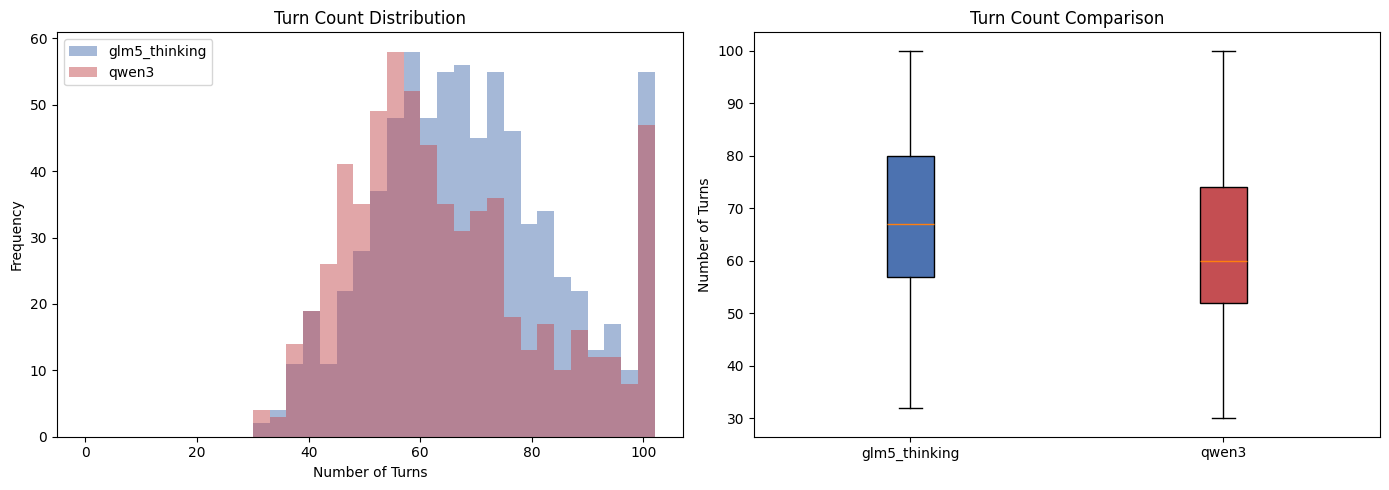

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
ax = axes[0]
all_turns = [t for vals in turns_by_name.values() for t in vals]
bins = np.arange(0, max(all_turns) + 3, 3)
for i, name in enumerate(NAMES):
    ax.hist(turns_by_name[name], bins=bins, alpha=0.5, label=name, color=get_color(i))
ax.set_xlabel("Number of Turns")
ax.set_ylabel("Frequency")
ax.set_title("Turn Count Distribution")
ax.legend()

# Box plot
ax = axes[1]
bp = ax.boxplot([turns_by_name[n] for n in NAMES], labels=NAMES, patch_artist=True)
for i, box in enumerate(bp["boxes"]):
    box.set_facecolor(get_color(i))
ax.set_ylabel("Number of Turns")
ax.set_title("Turn Count Comparison")

plt.tight_layout()
plt.show()

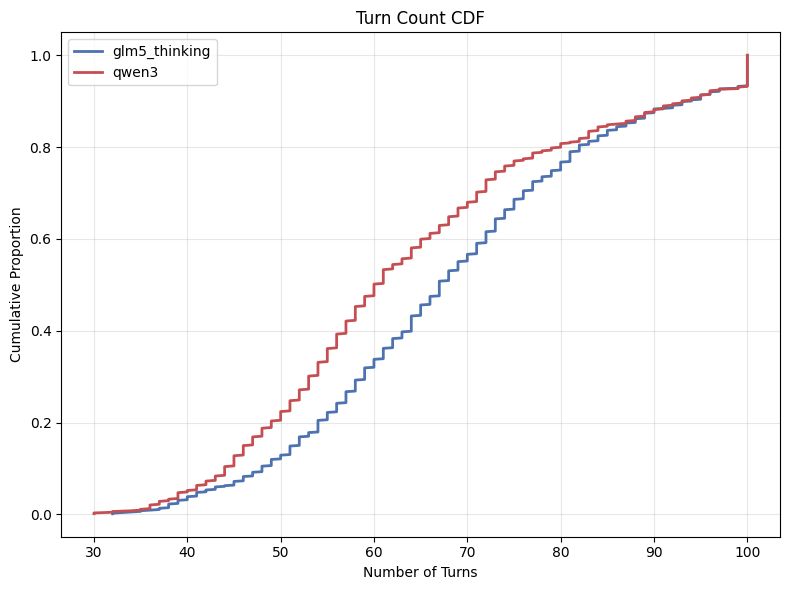

In [49]:
# CDF comparison of turn counts
fig, ax = plt.subplots(figsize=(8, 6))
for i, name in enumerate(NAMES):
    sorted_data = np.sort(turns_by_name[name])
    cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
    ax.plot(sorted_data, cdf, label=name, color=get_color(i), linewidth=2)
ax.set_xlabel("Number of Turns")
ax.set_ylabel("Cumulative Proportion")
ax.set_title("Turn Count CDF")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Content Length Statistics

In [50]:
total_len_by_name = {name: [s["total_content_len"] for s in all_stats[name]] for name in NAMES}
asst_len_by_name = {name: [s["asst_content_len"] for s in all_stats[name]] for name in NAMES}
user_len_by_name = {name: [s["user_content_len"] for s in all_stats[name]] for name in NAMES}

for label, by_name in [("Total Content Length (chars)", total_len_by_name),
                        ("Assistant Content Length (chars)", asst_len_by_name),
                        ("User/Observation Content Length (chars)", user_len_by_name)]:
    print(f"--- {label} ---")
    for name in NAMES:
        print_dist_stats(name, by_name[name])
    print()

--- Total Content Length (chars) ---
glm5_thinking:
  Mean: 238782.5, Median: 235435.0, Std: 47888.8, Min: 126111, Max: 416370
qwen3:
  Mean: 234636.2, Median: 226349.5, Std: 55859.9, Min: 110476, Max: 508032

--- Assistant Content Length (chars) ---
glm5_thinking:
  Mean: 61089.7, Median: 60167.0, Std: 16173.5, Min: 15295, Max: 139396
qwen3:
  Mean: 53051.4, Median: 49069.0, Std: 17205.3, Min: 18956, Max: 131639

--- User/Observation Content Length (chars) ---
glm5_thinking:
  Mean: 149792.8, Median: 146344.5, Std: 38361.5, Min: 64521, Max: 305032
qwen3:
  Mean: 153684.7, Median: 148058.5, Std: 45896.5, Min: 49680, Max: 391302



/tmp/ipykernel_3329167/3575540125.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([by_name[n] for n in NAMES], labels=NAMES, patch_artist=True)
/tmp/ipykernel_3329167/3575540125.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([by_name[n] for n in NAMES], labels=NAMES, patch_artist=True)
/tmp/ipykernel_3329167/3575540125.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([by_name[n] for n in NAMES], labels=NAMES, patch_artist=True)


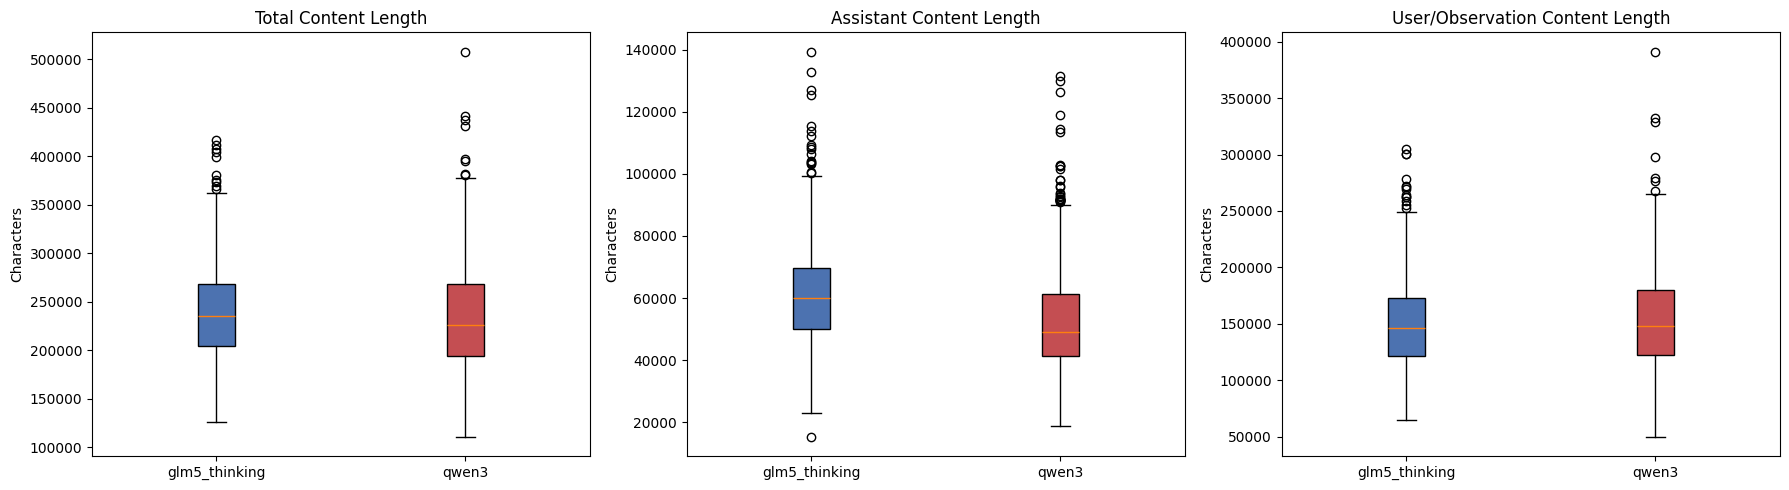

In [51]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, by_name, title in zip(
    axes,
    [total_len_by_name, asst_len_by_name, user_len_by_name],
    ["Total Content Length", "Assistant Content Length", "User/Observation Content Length"]
):
    bp = ax.boxplot([by_name[n] for n in NAMES], labels=NAMES, patch_artist=True)
    for i, box in enumerate(bp["boxes"]):
        box.set_facecolor(get_color(i))
    ax.set_ylabel("Characters")
    ax.set_title(title)

plt.tight_layout()
plt.show()

/tmp/ipykernel_3329167/993200735.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([mean_asst_by_name[n] for n in NAMES], labels=NAMES, patch_artist=True)
/tmp/ipykernel_3329167/993200735.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([mean_obs_by_name[n] for n in NAMES], labels=NAMES, patch_artist=True)


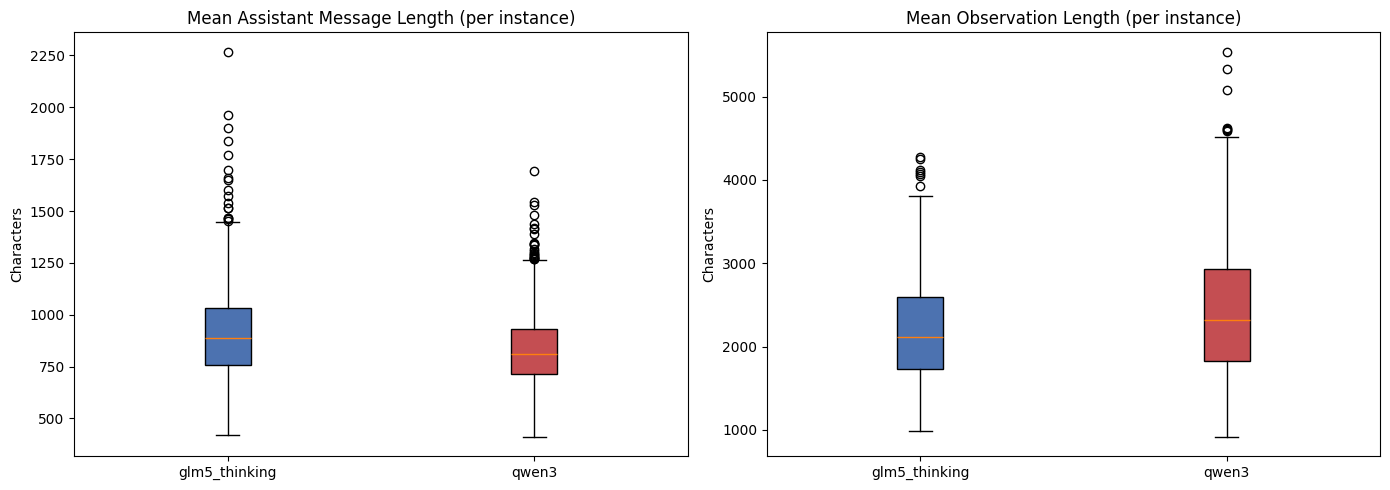

In [52]:
# Mean assistant message length and mean observation length per instance
mean_asst_by_name = {name: [s["mean_asst_len"] for s in all_stats[name]] for name in NAMES}
mean_obs_by_name = {name: [s["mean_obs_len"] for s in all_stats[name]] for name in NAMES}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
bp = ax.boxplot([mean_asst_by_name[n] for n in NAMES], labels=NAMES, patch_artist=True)
for i, box in enumerate(bp["boxes"]):
    box.set_facecolor(get_color(i))
ax.set_ylabel("Characters")
ax.set_title("Mean Assistant Message Length (per instance)")

ax = axes[1]
bp = ax.boxplot([mean_obs_by_name[n] for n in NAMES], labels=NAMES, patch_artist=True)
for i, box in enumerate(bp["boxes"]):
    box.set_facecolor(get_color(i))
ax.set_ylabel("Characters")
ax.set_title("Mean Observation Length (per instance)")

plt.tight_layout()
plt.show()

## 6. Tool Use Types

In [33]:
def aggregate_action_types(stats):
    total = Counter()
    for s in stats:
        total.update(s["action_types"])
    return total

actions_by_name = {name: aggregate_action_types(all_stats[name]) for name in NAMES}
all_types = sorted(set().union(*(a.keys() for a in actions_by_name.values())))
totals_by_name = {name: sum(actions_by_name[name].values()) for name in NAMES}

# Print table
header = f"{'Action Type':<25}" + "".join(f"{n:>12}" for n in NAMES) + "".join(f"{n+' %':>12}" for n in NAMES)
print(header)
print("-" * len(header))
for t in all_types:
    counts = [actions_by_name[n].get(t, 0) for n in NAMES]
    pcts = [100 * c / totals_by_name[n] if totals_by_name[n] > 0 else 0 for c, n in zip(counts, NAMES)]
    row = f"{t:<25}" + "".join(f"{c:>12}" for c in counts) + "".join(f"{p:>11.1f}%" for p in pcts)
    print(row)
print("-" * len(header))
row = f"{'TOTAL':<25}" + "".join(f"{totals_by_name[n]:>12}" for n in NAMES)
print(row)

Action Type              glm5_thinking       qwen3glm5_thinking %     qwen3 %
-----------------------------------------------------------------------------
execute_bash                    29354       21300       57.0%       52.3%
finish                            702         581        1.4%        1.4%
str_replace_editor              19586       16883       38.0%       41.5%
task_tracker                      630         311        1.2%        0.8%
text_only                           6           2        0.0%        0.0%
think                            1264        1645        2.5%        4.0%
-----------------------------------------------------------------------------
TOTAL                           51542       40722


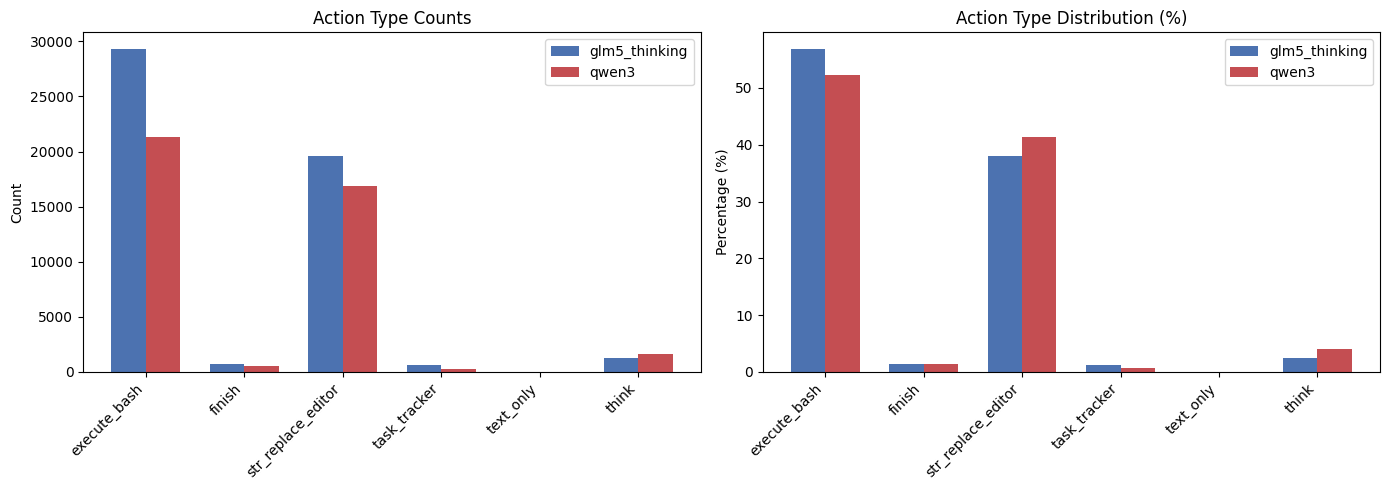

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(max(14, 3 * len(NAMES)), 5))

x = np.arange(len(all_types))
n_datasets = len(NAMES)
width = 0.7 / n_datasets

# Counts
ax = axes[0]
for i, name in enumerate(NAMES):
    vals = [actions_by_name[name].get(t, 0) for t in all_types]
    offset = (i - (n_datasets - 1) / 2) * width
    ax.bar(x + offset, vals, width, label=name, color=get_color(i))
ax.set_xticks(x)
ax.set_xticklabels(all_types, rotation=45, ha="right")
ax.set_ylabel("Count")
ax.set_title("Action Type Counts")
ax.legend()

# Proportions
ax = axes[1]
for i, name in enumerate(NAMES):
    vals = [100 * actions_by_name[name].get(t, 0) / totals_by_name[name] if totals_by_name[name] > 0 else 0 for t in all_types]
    offset = (i - (n_datasets - 1) / 2) * width
    ax.bar(x + offset, vals, width, label=name, color=get_color(i))
ax.set_xticks(x)
ax.set_xticklabels(all_types, rotation=45, ha="right")
ax.set_ylabel("Percentage (%)")
ax.set_title("Action Type Distribution (%)")
ax.legend()

plt.tight_layout()
plt.show()

## 7. Error Observation Analysis (Tool Misuse)

In [61]:
for name in NAMES:
    stats = all_stats[name]
    error_rates = [s["error_rate"] for s in stats]
    error_counts = [s["error_obs_count"] for s in stats]
    total_obs = [s["total_obs"] for s in stats]
    total_errors = sum(error_counts)
    total_ob = sum(total_obs)
    arr = np.array(error_rates)
    with_errors = sum(1 for r in error_rates if r > 0)
    print(f"{name}:")
    print(f"  Total observations:       {total_ob}")
    print(f"  Total error observations: {total_errors}")
    if total_ob > 0:
        print(f"  Overall error rate:       {100*total_errors/total_ob:.1f}%")
    print(f"  Per-instance error rate:  mean={100*arr.mean():.1f}%, "
          f"median={100*np.median(arr):.1f}%, max={100*arr.max():.1f}%")
    print(f"  Instances with any error: {with_errors}/{len(error_rates)} "
          f"({100*with_errors/len(error_rates):.1f}%)")
    print()

glm5_thinking:
  Total observations:       50790
  Total error observations: 8640
  Overall error rate:       17.0%
  Per-instance error rate:  mean=17.0%, median=15.5%, max=57.6%
  Instances with any error: 748/752 (99.5%)

qwen3:
  Total observations:       40088
  Total error observations: 6617
  Overall error rate:       16.5%
  Per-instance error rate:  mean=16.4%, median=15.1%, max=53.7%
  Instances with any error: 632/634 (99.7%)



/tmp/ipykernel_3329167/2007302919.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([error_rates_by_name[n] for n in NAMES], labels=NAMES, patch_artist=True)


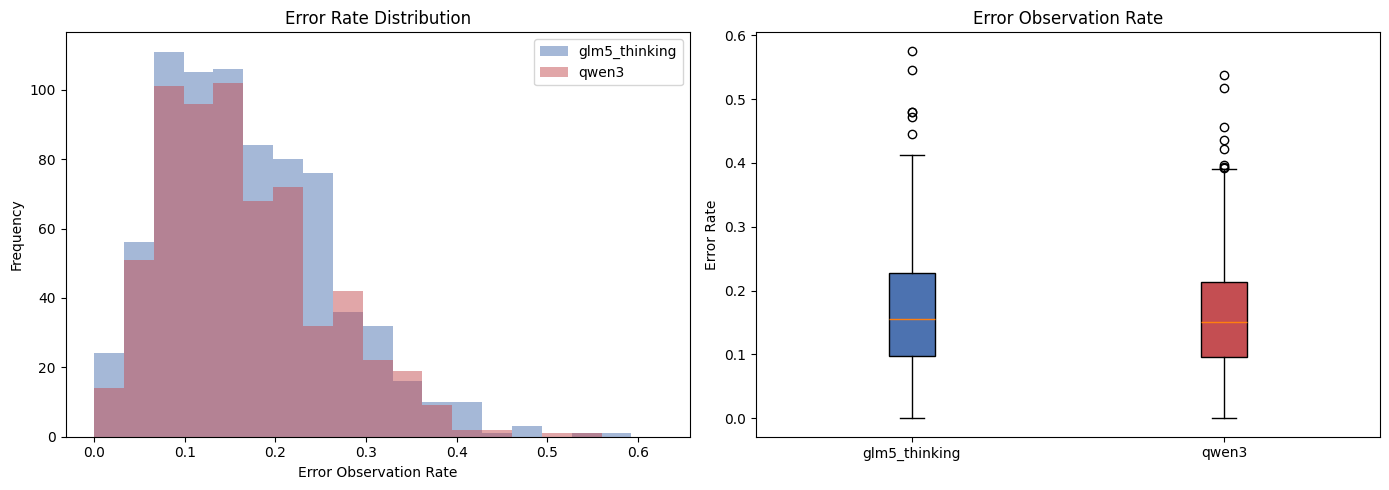

In [62]:
error_rates_by_name = {name: [s["error_rate"] for s in all_stats[name]] for name in NAMES}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
all_er = [r for vals in error_rates_by_name.values() for r in vals]
bins = np.linspace(0, max(all_er) + 0.05, 20)
for i, name in enumerate(NAMES):
    ax.hist(error_rates_by_name[name], bins=bins, alpha=0.5, label=name, color=get_color(i))
ax.set_xlabel("Error Observation Rate")
ax.set_ylabel("Frequency")
ax.set_title("Error Rate Distribution")
ax.legend()

ax = axes[1]
bp = ax.boxplot([error_rates_by_name[n] for n in NAMES], labels=NAMES, patch_artist=True)
for i, box in enumerate(bp["boxes"]):
    box.set_facecolor(get_color(i))
ax.set_ylabel("Error Rate")
ax.set_title("Error Observation Rate")

plt.tight_layout()
plt.show()

In [63]:
# Show examples of tool misuse: instances with highest error rates
for name in NAMES:
    stats = all_stats[name]
    # Sort by error rate descending, take top 3
    ranked = sorted(enumerate(stats), key=lambda x: -x[1]["error_rate"])
    top = [(idx, s) for idx, s in ranked if s["error_rate"] > 0][:3]
    if not top:
        print(f"{name}: No error observations found")
        continue
    print(f"\n{'='*80}")
    print(f"{name} — Top 3 Instances with Highest Error Rate")
    print(f"{'='*80}")
    for idx, s in top:
        print(f"\n  Entry #{idx}  (error rate: {100*s['error_rate']:.0f}%, "
              f"{s['error_obs_count']} errors / {s['total_obs']} observations, "
              f"{s['num_turns']} turns)")
        # Show the error observations with the preceding assistant action
        msgs = sft_data[name][idx]
        asst_idx = 0
        shown = 0
        for mi, m in enumerate(msgs):
            if m["role"] == "assistant":
                asst_idx = mi
            if m["role"] != "user" or 'EXECUTION RESULT of' not in m["content"]:
                continue
            content = m["content"]
            tool_match = re.search(r'EXECUTION RESULT of \[(\w+)\]', content)
            tool = tool_match.group(1) if tool_match else ""
            body = content.split('\n', 1)[1].strip() if '\n' in content else ''

            is_error = False
            error_msg = ""
            if tool == 'str_replace_editor' and body.startswith('ERROR:'):
                is_error = True
                error_msg = body.split('\n')[0][:120]
            elif tool == 'execute_bash':
                exit_match = re.search(r'\[Command finished with exit code (\d+)\]', content)
                if exit_match and int(exit_match.group(1)) != 0:
                    is_error = True
                    # Find the key error line
                    for line in body.split('\n'):
                        line = line.strip()
                        if any(kw in line for kw in ['Error', 'ERROR', 'Traceback', 'Exception',
                                                      'command not found', 'No such file']):
                            error_msg = line[:120]
                            break
                    if not error_msg:
                        error_msg = f"exit code {exit_match.group(1)}"
                elif '[The command has no new output after' in content:
                    is_error = True
                    error_msg = "Command timed out"

            if not is_error:
                continue

            # Show the action that caused this error
            asst_content = msgs[asst_idx]["content"] if asst_idx < len(msgs) else ""
            func_match = re.search(r'<function=(\w+)>', asst_content)
            if func_match:
                func_name = func_match.group(1)
                params = {}
                for pm in re.finditer(r'<parameter=(\w+)>(.*?)</parameter>', asst_content, re.DOTALL):
                    params[pm.group(1)] = pm.group(2).strip()
                params_short = {k: (v[:60] + '...' if len(v) > 60 else v)
                                for k, v in params.items() if k != 'security_risk'}
                print(f"    Action:  <function={func_name}> {params_short}")
            else:
                action_display = asst_content.replace('\n', ' ')[:120]
                print(f"    Action:  {action_display}")
            print(f"    Error:   {error_msg}")
            shown += 1
            if shown >= 3:
                break
        if s['error_obs_count'] > shown:
            print(f"    ... and {s['error_obs_count'] - shown} more errors")



glm5_thinking — Top 3 Instances with Highest Error Rate

  Entry #16  (error rate: 58%, 38 errors / 66 observations, 67 turns)
    Action:  <function=str_replace_editor> {'command': 'view', 'path': '/workspace/getmoto__moto__3.0/moto/ec2/exceptions.py'}
    Error:   1	from moto.core.exceptions import RESTError
    Error:   4	# EC2 has a custom root-tag - <Response> vs <ErrorResponse>
    Error:   7	EC2_ERROR_RESPONSE = """<?xml version="1.0" encoding="UTF-8"?>
    Action:  <function=str_replace_editor> {'command': 'view', 'path': '/workspace/getmoto__moto__3.0/moto/ec2/exceptions.py', 'view_range': '[234, 240]'}
    Error:   234	class InvalidInstanceIdError(EC2ClientError):
    Action:  <function=execute_bash> {'command': 'cd /workspace/getmoto__moto__3.0 && grep -r "InvalidInstance...'}
    Error:   moto/autoscaling/models.py:from moto.ec2.exceptions import InvalidInstanceIdError
    Error:   moto/autoscaling/models.py:            except InvalidInstanceIdError:
    Error:   moto/ec2/

## 8. Stuck in Loop Analysis

In [53]:
for name in NAMES:
    stats = all_stats[name]
    n = len(stats)
    stuck = sum(1 for s in stats if s["stuck_in_loop"])
    print(f"{name}: {stuck}/{n} stuck in loop ({100*stuck/n:.1f}%)")
    # Show loop details
    stuck_entries = [s for s in stats if s["stuck_in_loop"]]
    if stuck_entries:
        wasted = [s["loops"][0]["wasted_steps"] for s in stuck_entries]
        periods = Counter(s["loops"][0]["period"] for s in stuck_entries)
        print(f"  Wasted steps: mean={np.mean(wasted):.1f}, max={max(wasted)}")
        print(f"  Loop periods: {dict(periods.most_common())}")


glm5_thinking: 33/752 stuck in loop (4.4%)
  Wasted steps: mean=4.2, max=9
  Loop periods: {1: 29, 2: 4}
qwen3: 29/634 stuck in loop (4.6%)
  Wasted steps: mean=4.1, max=10
  Loop periods: {1: 24, 2: 5}


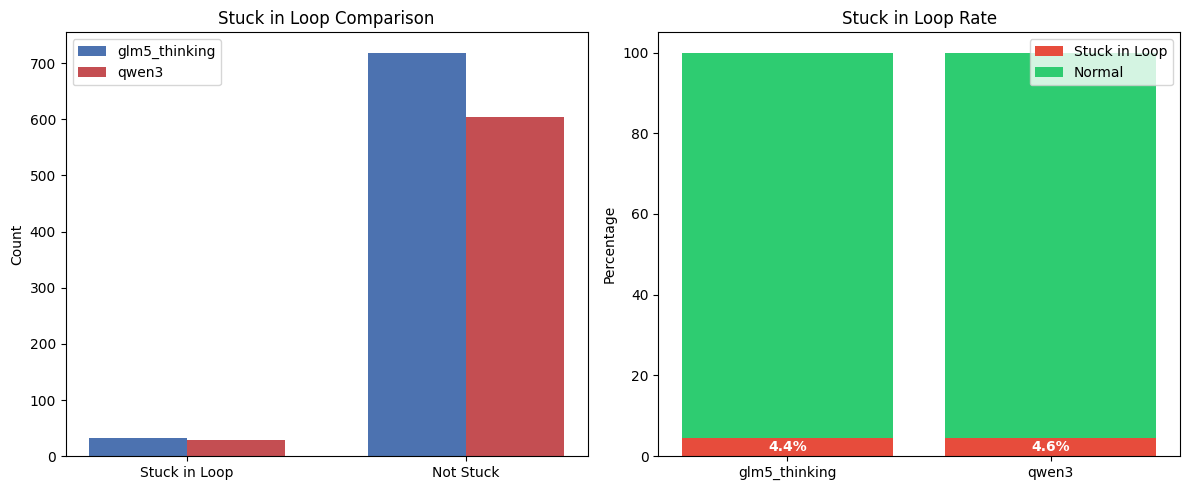

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(max(12, 3 * len(NAMES)), 5))

# Grouped bar: stuck vs not stuck
ax = axes[0]
x = np.arange(2)
n_datasets = len(NAMES)
width = 0.7 / n_datasets
for i, name in enumerate(NAMES):
    n = len(all_stats[name])
    stuck = sum(1 for s in all_stats[name] if s["stuck_in_loop"])
    offset = (i - (n_datasets - 1) / 2) * width
    ax.bar(x + offset, [stuck, n - stuck], width, label=name, color=get_color(i))
ax.set_xticks(x)
ax.set_xticklabels(["Stuck in Loop", "Not Stuck"])
ax.set_ylabel("Count")
ax.set_title("Stuck in Loop Comparison")
ax.legend()

# Stacked bar: stuck rate %
ax = axes[1]
stuck_pcts = []
for name in NAMES:
    n = len(all_stats[name])
    stuck = sum(1 for s in all_stats[name] if s["stuck_in_loop"])
    stuck_pcts.append(100 * stuck / n)
not_stuck_pcts = [100 - s for s in stuck_pcts]
ax.bar(NAMES, stuck_pcts, label="Stuck in Loop", color="#E74C3C")
ax.bar(NAMES, not_stuck_pcts, bottom=stuck_pcts, label="Normal", color="#2ECC71")
for i, (s, ns) in enumerate(zip(stuck_pcts, not_stuck_pcts)):
    ax.text(i, s / 2, f"{s:.1f}%", ha="center", va="center", fontweight="bold", color="white")
ax.set_ylabel("Percentage")
ax.set_title("Stuck in Loop Rate")
ax.legend()

plt.tight_layout()
plt.show()

### 8b. At Which Step Does the Stuck-in-Loop Occur?

Detect the step index where repetitive actions begin.

In [55]:
# Loop start step analysis
for name in NAMES:
    stats = all_stats[name]
    stuck_entries = [s for s in stats if s["loop_start_step"] is not None]
    if stuck_entries:
        starts = [s["loop_start_step"] for s in stuck_entries]
        ratios = [s["loop_start_step"] / s["num_turns"] for s in stuck_entries if s["num_turns"] > 0]
        periods = [s["loops"][0]["period"] for s in stuck_entries]
        arr_s = np.array(starts)
        arr_r = np.array(ratios)
        print(f"{name} (n={len(starts)}):")
        print(f"  Loop start step  — Mean: {arr_s.mean():.1f}, Median: {np.median(arr_s):.0f}, "
              f"Min: {arr_s.min()}, Max: {arr_s.max()}")
        print(f"  Loop start ratio — Mean: {arr_r.mean():.2f}, Median: {np.median(arr_r):.2f}  "
              f"(start_step / num_turns)")
        print(f"  Loop periods:    {dict(Counter(periods).most_common())}")
    else:
        print(f"{name}: No stuck-in-loop instances detected")


glm5_thinking (n=33):
  Loop start step  — Mean: 36.5, Median: 33, Min: 4, Max: 92
  Loop start ratio — Mean: 0.53, Median: 0.52  (start_step / num_turns)
  Loop periods:    {1: 29, 2: 4}
qwen3 (n=29):
  Loop start step  — Mean: 46.1, Median: 41, Min: 16, Max: 85
  Loop start ratio — Mean: 0.62, Median: 0.62  (start_step / num_turns)
  Loop periods:    {1: 24, 2: 5}


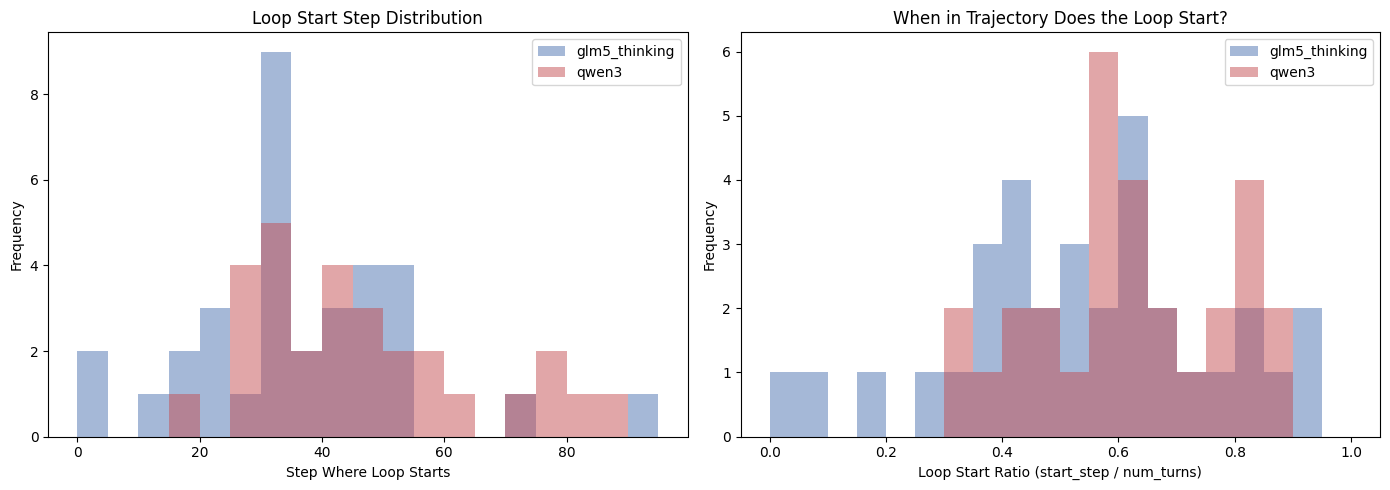

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of absolute loop start step
ax = axes[0]
all_starts = []
for i, name in enumerate(NAMES):
    starts = [s["loop_start_step"] for s in all_stats[name] if s["loop_start_step"] is not None]
    if starts:
        all_starts.extend(starts)
if all_starts:
    bins = np.arange(0, max(all_starts) + 5, 5)
    for i, name in enumerate(NAMES):
        starts = [s["loop_start_step"] for s in all_stats[name] if s["loop_start_step"] is not None]
        if starts:
            ax.hist(starts, bins=bins, alpha=0.5, label=name, color=get_color(i))
    ax.set_xlabel("Step Where Loop Starts")
    ax.set_ylabel("Frequency")
    ax.set_title("Loop Start Step Distribution")
    ax.legend()

# Histogram of loop start ratio
ax = axes[1]
bins_r = np.linspace(0, 1, 21)
for i, name in enumerate(NAMES):
    ratios = [s["loop_start_step"] / s["num_turns"] for s in all_stats[name]
              if s["loop_start_step"] is not None and s["num_turns"] > 0]
    if ratios:
        ax.hist(ratios, bins=bins_r, alpha=0.5, label=name, color=get_color(i))
ax.set_xlabel("Loop Start Ratio (start_step / num_turns)")
ax.set_ylabel("Frequency")
ax.set_title("When in Trajectory Does the Loop Start?")
ax.legend()

plt.tight_layout()
plt.show()

### 8c. What Action Patterns Trigger Stuck-in-Loop?

Analyze the repeating action fingerprint and categorize the loop patterns.

In [57]:
def categorize_sft_loop(loop_info):
    """Classify a stuck-loop into a human-readable category."""
    period = loop_info["period"]
    pattern = loop_info["pattern"]
    
    if period > 1:
        # Multi-step loop: describe the cycle
        types = []
        for fp in pattern:
            name = fp.split(":")[0]
            if name == "str_replace_editor":
                parts = fp.split(":")
                sub = parts[1] if len(parts) > 1 else ""
                types.append(f"edit({sub})")
            elif name == "execute_bash":
                cmd = fp[len("execute_bash:"):].lower()[:40]
                if "test" in cmd or "pytest" in cmd:
                    types.append("test")
                elif "python" in cmd:
                    types.append("python")
                else:
                    types.append("bash")
            else:
                types.append(name)
        return f"Cycle({period}): {' → '.join(types)}"
    
    # Single-step loop
    fp = pattern[0]
    if fp.startswith('str_replace_editor:'):
        parts = fp.split(':')
        sub = parts[1] if len(parts) > 1 else ''
        if sub == 'str_replace':
            return 'Repeated str_replace (same edit)'
        elif sub == 'view':
            return 'Repeated file view'
        elif sub == 'create':
            return 'Repeated file create'
        elif sub == 'insert':
            return 'Repeated insert'
        elif sub == 'undo_edit':
            return 'Repeated undo_edit'
        else:
            return f'Repeated edit ({sub})'
    elif fp.startswith('execute_bash:'):
        cmd = fp[len('execute_bash:'):].lower()
        if not cmd:
            return 'Repeated empty bash (stuck terminal)'
        elif 'test' in cmd or 'pytest' in cmd:
            return 'Repeated test execution'
        elif 'git' in cmd:
            return 'Repeated git command'
        elif any(x in cmd for x in ['cat ', 'head ', 'tail ']):
            return 'Repeated file inspection (cat/head/tail)'
        elif any(x in cmd for x in ['find ', 'grep ', 'ls ']):
            return 'Repeated search/find'
        elif 'pip ' in cmd or 'install' in cmd:
            return 'Repeated install command'
        elif 'python' in cmd:
            return 'Repeated python script execution'
        else:
            return 'Repeated shell command (other)'
    elif fp.startswith('execute_ipython:'):
        return 'Repeated IPython execution'
    elif fp.startswith('finish:') or fp == 'finish':
        return 'Repeated finish action'
    elif fp == 'text_only':
        return 'Repeated text-only message'
    elif fp == 'think':
        return 'Repeated think'
    else:
        name = fp.split(':')[0]
        return f'Repeated {name}'

def extract_sft_loop_patterns(stats_list):
    """For each stuck instance, extract the worst loop and categorize it."""
    patterns = []
    for idx, s in enumerate(stats_list):
        if not s["loops"]:
            continue
        best = s["loops"][0]  # worst loop by wasted_steps
        patterns.append({
            "index": idx,
            "period": best["period"],
            "pattern": best["pattern"],
            "category": categorize_sft_loop(best),
            "repeats": best["repeats"],
            "wasted_steps": best["wasted_steps"],
            "start_step": best["start"],
            "total_steps": s["num_turns"],
        })
    return patterns

patterns_by_name = {name: extract_sft_loop_patterns(all_stats[name]) for name in NAMES}

# Category breakdown
for name in NAMES:
    pats = patterns_by_name[name]
    if not pats:
        print(f"{name}: No stuck-in-loop patterns")
        continue
    cats = Counter(p["category"] for p in pats)
    print(f"\n{name} — Loop Pattern Categories (n={len(pats)}):")
    for cat, cnt in cats.most_common():
        print(f"  {cat:<45} {cnt:>5} ({100*cnt/len(pats):.1f}%)")



glm5_thinking — Loop Pattern Categories (n=33):
  Repeated python script execution                  9 (27.3%)
  Repeated empty bash (stuck terminal)              7 (21.2%)
  Repeated str_replace (same edit)                  6 (18.2%)
  Repeated shell command (other)                    5 (15.2%)
  Cycle(2): edit(str_replace) → bash                2 (6.1%)
  Repeated search/find                              1 (3.0%)
  Cycle(2): python → edit(str_replace)              1 (3.0%)
  Repeated test execution                           1 (3.0%)
  Cycle(2): edit(str_replace) → test                1 (3.0%)

qwen3 — Loop Pattern Categories (n=29):
  Repeated python script execution                  8 (27.6%)
  Repeated str_replace (same edit)                  7 (24.1%)
  Repeated test execution                           5 (17.2%)
  Repeated task_tracker                             4 (13.8%)
  Cycle(2): edit(str_replace) → bash                2 (6.9%)
  Cycle(2): python → edit(str_replace)          

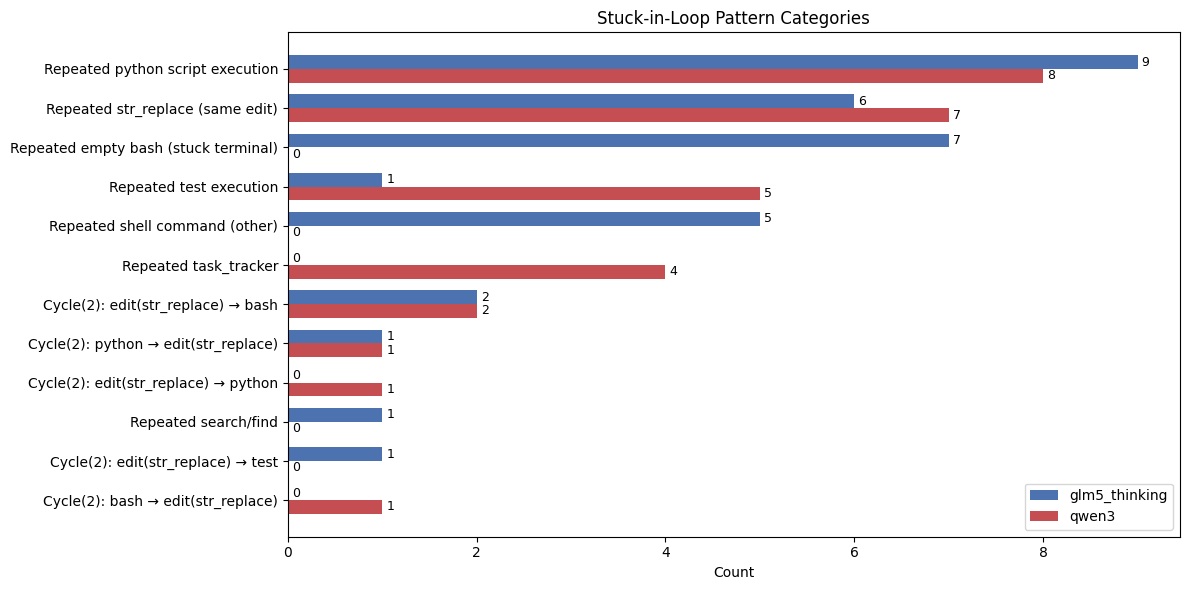

In [58]:
# Visualization: pattern categories comparison
all_cats_set = set()
cats_by_name = {}
for name in NAMES:
    cats = Counter(p["category"] for p in patterns_by_name[name])
    cats_by_name[name] = cats
    all_cats_set |= set(cats.keys())

all_cats = sorted(all_cats_set,
                  key=lambda c: -sum(cats_by_name[n].get(c, 0) for n in NAMES))

if all_cats:
    fig, ax = plt.subplots(figsize=(12, max(4, 0.5 * len(all_cats))))
    y = np.arange(len(all_cats))
    n_datasets = len(NAMES)
    height = 0.7 / n_datasets
    for i, name in enumerate(NAMES):
        vals = [cats_by_name[name].get(c, 0) for c in all_cats]
        offset = (i - (n_datasets - 1) / 2) * height
        bars = ax.barh(y + offset, vals, height, label=name, color=get_color(i))
        ax.bar_label(bars, fontsize=9, padding=3)
    ax.set_yticks(y)
    ax.set_yticklabels(all_cats)
    ax.set_xlabel("Count")
    ax.set_title("Stuck-in-Loop Pattern Categories")
    ax.legend()
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print("No stuck-in-loop patterns found in any dataset.")

In [60]:
# Show concrete examples of top loop patterns per dataset
for name in NAMES:
    pats = patterns_by_name[name]
    if not pats:
        continue
    sorted_pats = sorted(pats, key=lambda p: -p["wasted_steps"])
    print(f"\n{'='*80}")
    print(f"{name} — Top 5 Stuck Loop Examples (most wasted steps)")
    print(f"{'='*80}")
    for p in sorted_pats[:5]:
        idx = p['index']
        print(f"\n  Entry #{idx}")
        print(f"  Category:     {p['category']}")
        print(f"  Period:       {p['period']} (steps per cycle)")
        print(f"  Repeats:      {p['repeats']} cycles = {p['wasted_steps']} wasted steps "
              f"(starts at step {p['start_step']}/{p['total_steps']})")
        # Show actual message content for each step in the pattern
        asst_msgs = [m for m in sft_data[name][idx] if m["role"] == "assistant"]
        for j in range(p['period']):
            step_idx = p['start_step'] + j
            if step_idx < len(asst_msgs):
                content = asst_msgs[step_idx]["content"]
                # Extract the tool call info
                func_match = re.search(r'<function=(\w+)>', content)
                if func_match:
                    func_name = func_match.group(1)
                    params = {}
                    for pm in re.finditer(r'<parameter=(\w+)>(.*?)</parameter>', content, re.DOTALL):
                        params[pm.group(1)] = pm.group(2).strip()
                    params_display = {k: (v[:80] + '...' if len(v) > 80 else v) for k, v in params.items()
                                      if k != 'security_risk'}
                    print(f"  Step[{j}]:      <function={func_name}> {params_display}")
                else:
                    # Show raw content excerpt
                    content_display = content.replace('\n', ' ')[:150]
                    print(f"  Step[{j}]:      {content_display}")



glm5_thinking — Top 5 Stuck Loop Examples (most wasted steps)

  Entry #523
  Category:     Repeated empty bash (stuck terminal)
  Period:       1 (steps per cycle)
  Repeats:      9 cycles = 9 wasted steps (starts at step 24/72)
  Step[0]:      <function=execute_bash> {'command': '', 'is_input': 'True'}

  Entry #454
  Category:     Repeated empty bash (stuck terminal)
  Period:       1 (steps per cycle)
  Repeats:      8 cycles = 8 wasted steps (starts at step 41/49)
  Step[0]:      <function=execute_bash> {'command': '', 'is_input': 'True'}

  Entry #22
  Category:     Cycle(2): edit(str_replace) → bash
  Period:       2 (steps per cycle)
  Repeats:      3 cycles = 6 wasted steps (starts at step 49/77)
  Step[0]:      <function=str_replace_editor> {'command': 'str_replace', 'new_str': '@classmethod\n    def delete_from_cloudformation_json(  # type: ignore[misc]\n    ...', 'old_str': '@classmethod\n    def delete_from_cloudformation_json(  # type: ignore[misc]\n    ...', 'path': '/w

## 9. Finish Action Analysis

glm5_thinking: 702/752 end with finish (93.4%)
qwen3: 581/634 end with finish (91.6%)


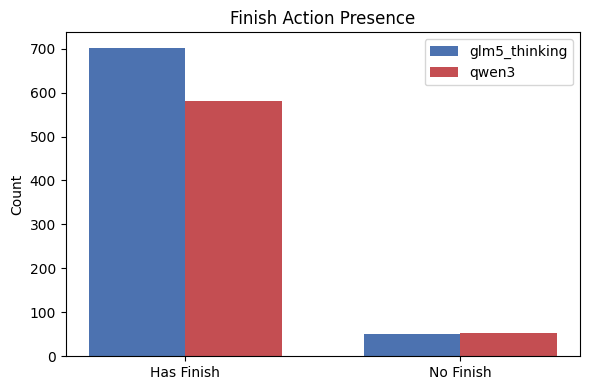

In [18]:
for name in NAMES:
    n = len(all_stats[name])
    finish = sum(1 for s in all_stats[name] if s["has_finish"])
    print(f"{name}: {finish}/{n} end with finish ({100*finish/n:.1f}%)")

fig, ax = plt.subplots(figsize=(max(6, 2 * len(NAMES)), 4))
x = np.arange(2)
n_datasets = len(NAMES)
width = 0.7 / n_datasets
for i, name in enumerate(NAMES):
    n = len(all_stats[name])
    finish = sum(1 for s in all_stats[name] if s["has_finish"])
    offset = (i - (n_datasets - 1) / 2) * width
    ax.bar(x + offset, [finish, n - finish], width, label=name, color=get_color(i))
ax.set_xticks(x)
ax.set_xticklabels(["Has Finish", "No Finish"])
ax.set_ylabel("Count")
ax.set_title("Finish Action Presence")
ax.legend()
plt.tight_layout()
plt.show()

## 10. Summary Table

In [ ]:
def compute_sft_summary(stats, label):
    turns = [s["num_turns"] for s in stats]
    total_lens = [s["total_content_len"] for s in stats]
    asst_lens = [s["asst_content_len"] for s in stats]
    error_rates = [s["error_rate"] for s in stats]
    stuck = sum(1 for s in stats if s["stuck_in_loop"])
    finish = sum(1 for s in stats if s["has_finish"])
    n = len(stats)
    return {
        "Run": label,
        "Instances": n,
        "Mean Turns": f"{np.mean(turns):.1f}",
        "Median Turns": f"{np.median(turns):.0f}",
        "Mean Total Len": f"{np.mean(total_lens):.0f}",
        "Mean Asst Len": f"{np.mean(asst_lens):.0f}",
        "Mean Error %": f"{100*np.mean(error_rates):.1f}%",
        "Stuck Loop %": f"{100*stuck/n:.1f}%",
        "Has Finish %": f"{100*finish/n:.1f}%",
    }

rows = [compute_sft_summary(all_stats[name], name) for name in NAMES]

keys = list(rows[0].keys())
col_widths = [max(len(str(r[k])) for r in rows + [{k: k for k in keys}]) for k in keys]
header = " | ".join(k.ljust(w) for k, w in zip(keys, col_widths))
print(header)
print("-" * len(header))
for r in rows:
    print(" | ".join(str(r[k]).ljust(w) for k, w in zip(keys, col_widths)))

## 11. Distribution Comparison

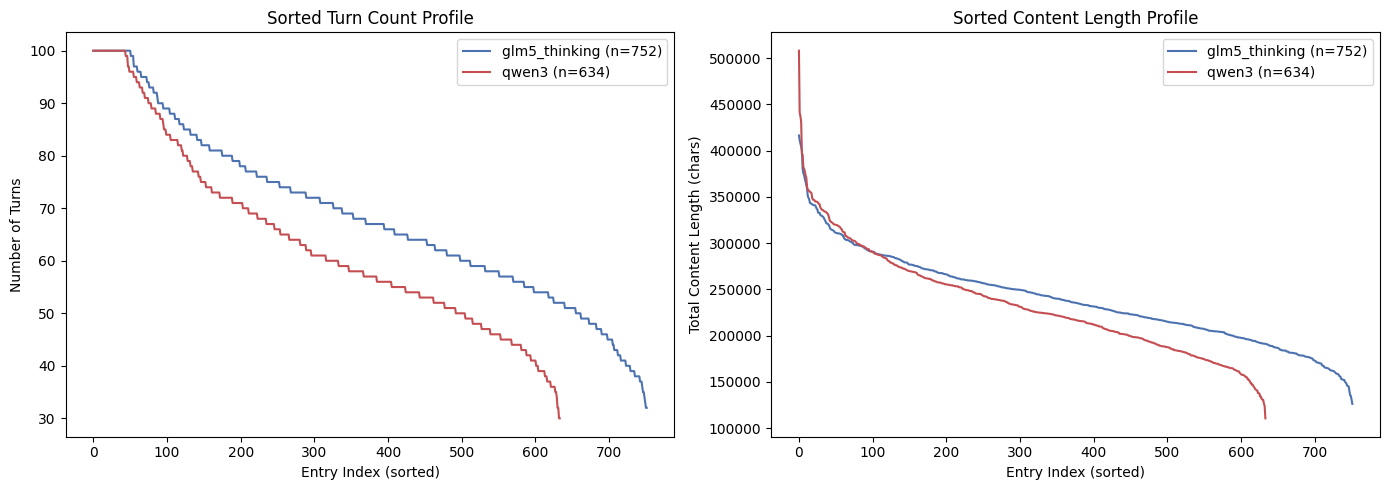

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sorted turn counts
ax = axes[0]
for i, name in enumerate(NAMES):
    vals = sorted([s["num_turns"] for s in all_stats[name]], reverse=True)
    ax.plot(range(len(vals)), vals,
            label=f"{name} (n={len(vals)})", color=get_color(i), linewidth=1.5)
ax.set_xlabel("Entry Index (sorted)")
ax.set_ylabel("Number of Turns")
ax.set_title("Sorted Turn Count Profile")
ax.legend()

# Sorted total content length
ax = axes[1]
for i, name in enumerate(NAMES):
    vals = sorted([s["total_content_len"] for s in all_stats[name]], reverse=True)
    ax.plot(range(len(vals)), vals,
            label=f"{name} (n={len(vals)})", color=get_color(i), linewidth=1.5)
ax.set_xlabel("Entry Index (sorted)")
ax.set_ylabel("Total Content Length (chars)")
ax.set_title("Sorted Content Length Profile")
ax.legend()

plt.tight_layout()
plt.show()

In [20]:
# Percentile comparison table
percentiles = [10, 25, 50, 75, 90, 95, 99]
metrics = [
    ("Turns", lambda s: s["num_turns"]),
    ("Total Len", lambda s: s["total_content_len"]),
    ("Asst Len", lambda s: s["asst_content_len"]),
    ("Error Rate", lambda s: s["error_rate"]),
]

for metric_name, extractor in metrics:
    print(f"\n--- {metric_name} Percentiles ---")
    header = f"{'Percentile':<12}" + "".join(f"{'P'+str(p):>10}" for p in percentiles)
    print(header)
    for name in NAMES:
        vals = [extractor(s) for s in all_stats[name]]
        pcts = np.percentile(vals, percentiles)
        print(f"{name:<12}" + "".join(f"{v:>10.1f}" for v in pcts))


--- Turns Percentiles ---
Percentile         P10       P25       P50       P75       P90       P95       P99
glm5_thinking      48.0      57.0      67.0      80.0      93.9     100.0     100.0
qwen3             44.0      52.0      60.0      74.0      93.0     100.0     100.0

--- Total Len Percentiles ---
Percentile         P10       P25       P50       P75       P90       P95       P99
glm5_thinking  179905.1  204616.8  235435.0  268418.5  298254.7  321378.0  371304.2
qwen3         168854.6  193610.2  226349.5  268287.5  307855.7  335967.7  381513.0

--- Asst Len Percentiles ---
Percentile         P10       P25       P50       P75       P90       P95       P99
glm5_thinking   41801.9   49894.8   60167.0   69847.8   81504.3   87709.5  108888.1
qwen3          34696.5   41502.8   49069.0   61185.2   76020.6   87842.6  102690.7

--- Error Rate Percentiles ---
Percentile         P10       P25       P50       P75       P90       P95       P99
glm5_thinking       0.1       0.1       0.2    

--- Action Type Diversity (unique action types per instance) ---
glm5_thinking:
  Mean: 3.9, Median: 4.0, Std: 0.6, Min: 2, Max: 6
qwen3:
  Mean: 4.1, Median: 4.0, Std: 0.4, Min: 3, Max: 6


/tmp/ipykernel_3329167/200803009.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([diversity_by_name[n] for n in NAMES], labels=NAMES, patch_artist=True)


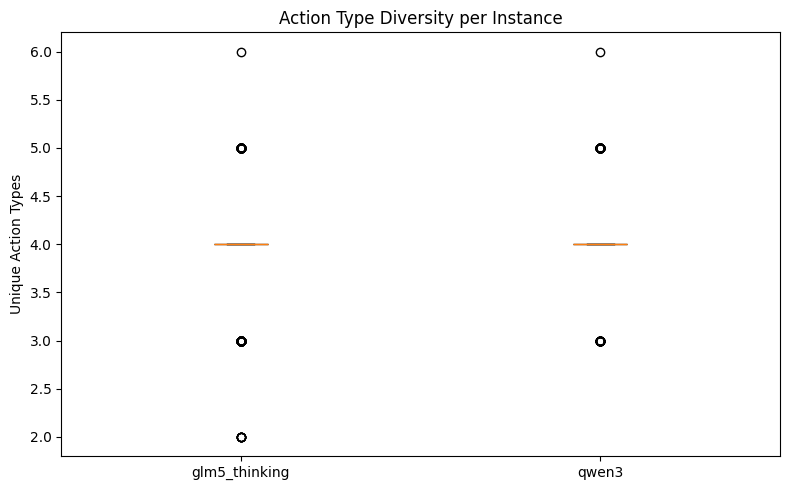

In [21]:
# Action type diversity comparison
diversity_by_name = {name: [len(s["action_types"]) for s in all_stats[name]] for name in NAMES}

print("--- Action Type Diversity (unique action types per instance) ---")
for name in NAMES:
    print_dist_stats(name, diversity_by_name[name])

fig, ax = plt.subplots(figsize=(max(8, 2 * len(NAMES)), 5))
bp = ax.boxplot([diversity_by_name[n] for n in NAMES], labels=NAMES, patch_artist=True)
for i, box in enumerate(bp["boxes"]):
    box.set_facecolor(get_color(i))
ax.set_ylabel("Unique Action Types")
ax.set_title("Action Type Diversity per Instance")
plt.tight_layout()
plt.show()